In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Operational data loading and exploration

In [2]:
xls = pd.ExcelFile('single_operational_data.xlsx')
conventional_params = pd.read_excel(xls, 'conventional')
storage_params = pd.read_excel(xls, 'storage')
other_param = pd.read_excel(xls, 'other')

In [3]:
new_col_names = ['technology', 'VarOM (mn£/GWh)', 'FuelCost (mn£/GWh)', 'CO2_emissions (ktco2/GWh)', 'efficiency', 'ramping (GW/GW)']
conventional_params.columns = new_col_names
conventional_params = conventional_params.drop(0)
conventional_params

,technology,VarOM (mn£/GWh),FuelCost (mn£/GWh),CO2_emissions (ktco2/GWh),efficiency,ramping (GW/GW)
1,Coal,0.00317,0.00574,0.318,0.39,0.7
2,CoalCCS,0.00675,0.00574,0.032,0.28,0.7
3,OCGT,0.00736,0.01211,0.181,0.35,4.8
4,CCGT,0.00232,0.01211,0.181,0.53,1.2
5,Diesel,0,0.0281,0.25,0.34,18
6,Nuclear,0.00152,0.008,0,0.33,0.18


In [4]:
new_col_names = ['technology', 'efficiency', 'power_ratio (GWh/GW)', 'VarOM (mn£/GWh)']
storage_params.columns = new_col_names
storage_params = storage_params.drop(0)
storage_params

,technology,efficiency,power_ratio (GWh/GW),VarOM (mn£/GWh)
1,PHES,0.67,5.55,0.00234
2,Lithium,0.92,2.5,0


In [5]:
new_col_names = ['demand_shedding (mn£/GW)', 'demand_scaling', 'co2_cost (mn£/ktCO2)', 'co2_lim (ktCO2)', 'co2_lim_scaling', 'hour']
other_param.columns = new_col_names
other_param = other_param.drop(0)
other_param['co2_lim (ktCO2)'] = 57133.47
#other_param['co2_lim (ktCO2)'] = 1453.18
other_param

,demand_shedding (mn£/GW),demand_scaling,co2_cost (mn£/ktCO2),co2_lim (ktCO2),co2_lim_scaling,hour
1,3,1,0.018,57133.47,1,0.5


In [6]:
conventional_params.to_csv('cleaned/conventional_params.csv')
storage_params.to_csv('cleaned/storage_params.csv')
other_param.to_csv('cleaned/other_params.csv')

# Time series data loading and exploration

In [7]:
xls_ts = pd.ExcelFile('UK_data.xlsx')
wind = pd.read_excel(xls_ts, 'wind')
solar = pd.read_excel(xls_ts, 'solar')
demand = pd.read_excel(xls_ts, 'demand')

In [8]:
wind.set_index('time', inplace=True)
wind.index = pd.to_datetime(wind.index)
wind.columns = ['capacity factor']
wind

,capacity factor
time,
2015-01-01 00:00:00,0.6827
2015-01-01 01:00:00,0.6759
2015-01-01 02:00:00,0.6666
2015-01-01 03:00:00,0.6562
2015-01-01 04:00:00,0.6532
...,...
2019-12-31 19:00:00,0.2325
2019-12-31 20:00:00,0.2328
2019-12-31 21:00:00,0.2255


In [9]:
new_index = pd.date_range(start=wind.index.min(), end=wind.index.max(), freq='30min')
wind_resampled = wind.reindex(new_index)
wind_resampled['capacity factor'] = wind_resampled['capacity factor'].interpolate(method='time')
wind = wind_resampled


In [10]:
wind['capacity factor'].describe()

count    87647.000000
mean         0.291576
std          0.196061
min          0.007400
25%          0.137100
50%          0.246150
75%          0.400200
max          0.964900
Name: capacity factor, dtype: float64

In [11]:
int(wind['capacity factor'].isna().sum())

0

In [12]:
solar.set_index('time', inplace=True)
solar.index = pd.to_datetime(solar.index)
solar.columns = ['capacity factor']
solar

,capacity factor
time,
2015-01-01 00:00:00,0.0
2015-01-01 01:00:00,0.0
2015-01-01 02:00:00,0.0
2015-01-01 03:00:00,0.0
2015-01-01 04:00:00,0.0
...,...
2019-12-31 19:00:00,0.0
2019-12-31 20:00:00,0.0
2019-12-31 21:00:00,0.0


In [13]:
new_index = pd.date_range(start=solar.index.min(), end=solar.index.max(), freq='30min')
solar_resampled = solar.reindex(new_index)
solar_resampled['capacity factor'] = solar_resampled['capacity factor'].interpolate(method='time')
solar = solar_resampled

In [14]:
solar['capacity factor'].describe()

count    87647.000000
mean         0.109592
std          0.163621
min          0.000000
25%          0.000000
50%          0.004000
75%          0.182000
max          0.698000
Name: capacity factor, dtype: float64

In [15]:
int(solar['capacity factor'].isna().sum())

0

In [16]:
demand.set_index('time', inplace=True)
demand.index = pd.to_datetime(demand.index)
demand = demand.drop(['hour', 'dayofweek', 'month'], axis = 1)
demand.columns = ['demand']
demand

,demand
time,
2015-01-01 00:00:00,27227.33333
2015-01-01 01:00:00,27426.33333
2015-01-01 02:00:00,24717.66667
2015-01-01 03:00:00,23233.00000
2015-01-01 04:00:00,22046.66667
...,...
2019-12-31 19:00:00,40320.50000
2019-12-31 20:00:00,37607.16667
2019-12-31 21:00:00,34883.33333


In [17]:
new_index = pd.date_range(start=demand.index.min(), end=demand.index.max(), freq='30min')
demand_resampled = demand.reindex(new_index)
demand_resampled['demand'] = demand_resampled['demand'].interpolate(method='time')
demand = demand_resampled

In [18]:
demand['demand'] = demand['demand'] / 1000
demand

,demand
2015-01-01 00:00:00,27.227333
2015-01-01 00:30:00,27.326833
2015-01-01 01:00:00,27.426333
2015-01-01 01:30:00,26.072000
2015-01-01 02:00:00,24.717667
...,...
2019-12-31 21:00:00,34.883333
2019-12-31 21:30:00,33.082000
2019-12-31 22:00:00,31.280667
2019-12-31 22:30:00,31.096833


In [19]:
demand['demand'].describe()

count    87647.000000
mean        35.833136
std          7.766947
min          0.744667
25%         29.864250
50%         36.441833
75%         41.478292
max         57.935333
Name: demand, dtype: float64

In [20]:
int(demand['demand'].isna().sum())

0

In [21]:
len(demand[demand['demand'] > 56])

82

In [22]:

wind.to_csv('cleaned/wind.csv', index = True)
solar.to_csv('cleaned/solar.csv', index = True)
demand.to_csv('cleaned/demand.csv', index = True)

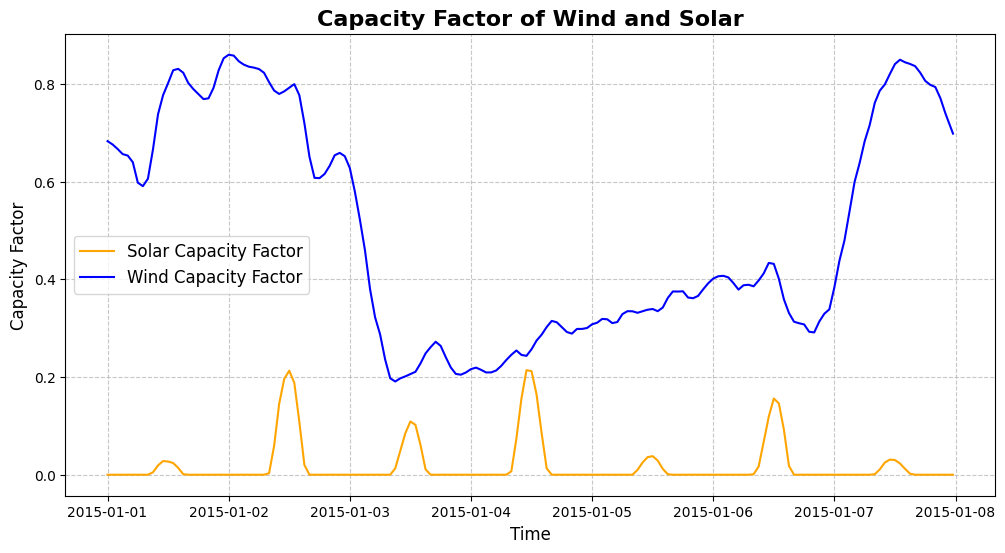

In [23]:
solar_sample = solar.iloc[:336]
wind_sample = wind.iloc[:336]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(solar_sample.index, solar_sample['capacity factor'], label='Solar Capacity Factor', color='orange')
plt.plot(wind_sample.index, wind_sample['capacity factor'], label='Wind Capacity Factor', color='blue')

# Title and labels
plt.title("Capacity Factor of Wind and Solar", fontsize=16, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Capacity Factor", fontsize=12)

# Legend
plt.legend(fontsize=12)

# Show grid
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

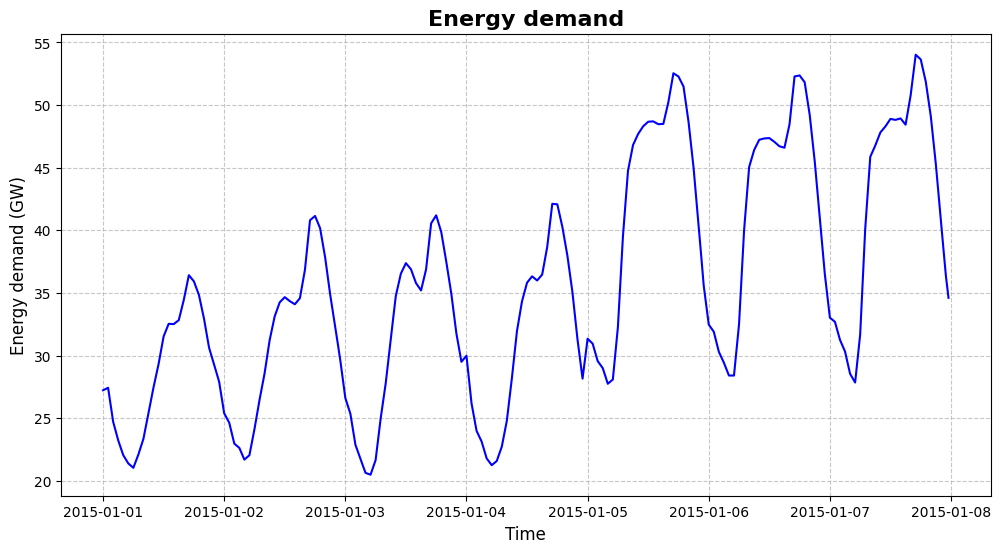

In [35]:

demand_sample = demand.iloc[:336]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(wind_sample.index, demand_sample['demand'], label='Demand', color='blue')

# Title and labels
plt.title("Energy demand", fontsize=16, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Energy demand (GW)", fontsize=12)


# Show grid
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Investments data loading and exploration

In [24]:
xls1 = pd.ExcelFile('single_investment__data.xlsx')

investment_param = pd.read_excel(xls1, 'investment')
coal_cap = pd.read_excel(xls1, 'coal')
coalccs_cap = pd.read_excel(xls1, 'coalccs')
ocgt_cap = pd.read_excel(xls1, 'ocgt')
ccgt_cap = pd.read_excel(xls1, 'ccgt')
diesel_cap = pd.read_excel(xls1, 'diesel')
nuclear_cap = pd.read_excel(xls1, 'nuclear')
PHES_cap = pd.read_excel(xls1, 'PHES')
lithium_cap = pd.read_excel(xls1, 'lithium')
windon_cap = pd.read_excel(xls1, 'windon')
windoff_cap = pd.read_excel(xls1, 'windoff')
solar_cap = pd.read_excel(xls1, 'solar')

In [25]:
new_col_names = ['technology', 'CapeX (mn£/GW)', 'FixOM (mn£/GWyr)', 'Life (yr)', 'Max_capacity (GW)', 'ref']
investment_param.columns = new_col_names
investment_param = investment_param.drop(0)
investment_param

,technology,CapeX (mn£/GW),FixOM (mn£/GWyr),Life (yr),Max_capacity (GW),ref
1,Coal,2083,26.84,35,200,coal
2,CoalCCS,3354,47.17,35,100,coalccs
3,OCGT,480,5,30,200,ocgt
4,CCGT,726,10.91,30,200,ccgt
5,Diesel,320,3,25,100,diesel
6,Nuclear,3926,66.23,40,15,nuclear
7,PHES,510,9.9,20,1000,PHES
8,Lithium,750,1.5,15,400,lithium
9,Wind_onshore,1571,28.08,50,250,windon
10,Wind_offshore,4423,52.54,50,500,windoff


In [26]:
coal_cap = coal_cap.drop(0)
coalccs_cap = coalccs_cap.drop(0)
ocgt_cap = ocgt_cap.drop(0)
ccgt_cap = ccgt_cap.drop(0)
diesel_cap = diesel_cap.drop(0)
nuclear_cap = nuclear_cap.drop(0)
PHES_cap = PHES_cap.drop(0)
lithium_cap = lithium_cap.drop(0)
windon_cap = windon_cap.drop(0)
windoff_cap = windoff_cap.drop(0)
solar_cap = solar_cap.drop(0)

In [27]:
investment_param.loc[1, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = coal_cap.iloc[0]
investment_param.loc[2, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = coalccs_cap.iloc[0]
investment_param.loc[3, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = ocgt_cap.iloc[0]
investment_param.loc[4, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = ccgt_cap.iloc[0]
investment_param.loc[5, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = diesel_cap.iloc[0]
investment_param.loc[6, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = nuclear_cap.iloc[0]
investment_param.loc[7, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = PHES_cap.iloc[0]
investment_param.loc[8, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = lithium_cap.iloc[0]
investment_param.loc[9, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = windon_cap.iloc[0]
investment_param.loc[10, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = windoff_cap.iloc[0]
investment_param.loc[11, ['capacity_at_0', 'capacity_at_5', 'capacity_at_10']] = solar_cap.iloc[0]

In [28]:
investment_param

,technology,CapeX (mn£/GW),FixOM (mn£/GWyr),Life (yr),Max_capacity (GW),ref,capacity_at_0,capacity_at_5,capacity_at_10
1,Coal,2083,26.84,35,200,coal,13.999990,12.599991,10.079993
2,CoalCCS,3354,47.17,35,100,coalccs,2.000000,2.000000,2.000000
3,OCGT,480,5,30,200,ocgt,8.000000,7.200000,6.480000
4,CCGT,726,10.91,30,200,ccgt,24.999990,22.499991,20.249992
5,Diesel,320,3,25,100,diesel,5.000000,4.500000,4.050000
6,Nuclear,3926,66.23,40,15,nuclear,6.999990,6.649991,6.317491
7,PHES,510,9.9,20,1000,PHES,4.040000,3.838000,3.646100
8,Lithium,750,1.5,15,400,lithium,0.500000,0.500000,0.500000
9,Wind_onshore,1571,28.08,50,250,windon,20.512976,19.487327,18.512961
10,Wind_offshore,4423,52.54,50,500,windoff,14.854224,14.111513,13.405937


In [29]:
investment_param.to_csv('cleaned/single_investment_data.csv')

# uncertainty data load and exploration

In [30]:
xls2 = pd.ExcelFile('single_uncertainty_data.xlsx')

demand_scaling_factor = pd.read_excel(xls2, 'demand')
co2_budget_scaling_factor = pd.read_excel(xls2, 'co2_budget')
co2_price = pd.read_excel(xls2, 'co2_price')
uranium_price = pd.read_excel(xls2, 'uranium_price')

In [31]:
demand_scaling_factor.columns = demand_scaling_factor.iloc[0].tolist()
demand_scaling_factor = demand_scaling_factor.drop(0)

value_list = [demand_scaling_factor['present'].iloc[0], demand_scaling_factor['5 years'].iloc[0],
              demand_scaling_factor['5 years'].iloc[3], demand_scaling_factor['5 years'].iloc[6]]

for v in demand_scaling_factor['10 years']:
    value_list.append(v)

new_data = {'node':range(13), 'value':value_list}
demand_scaling_factor = pd.DataFrame(new_data)

demand_scaling_factor

,node,value
0,0,-1.00
1,1,-1.20
2,2,-1.10
3,3,-1.00
4,4,-1.45
5,5,-1.35
6,6,-1.25
7,7,-1.35
8,8,-1.25
9,9,-1.15


In [32]:
co2_budget_scaling_factor.columns = co2_budget_scaling_factor.iloc[0].tolist()
co2_budget_scaling_factor = co2_budget_scaling_factor.drop(0)

value_list = [co2_budget_scaling_factor['present'].iloc[0], co2_budget_scaling_factor['5 years'].iloc[0],
              co2_budget_scaling_factor['5 years'].iloc[3], co2_budget_scaling_factor['5 years'].iloc[6]]

for v in co2_budget_scaling_factor['10 years']:
    value_list.append(v)

new_data = {'node':range(13), 'value':value_list}
co2_budget_scaling_factor = pd.DataFrame(new_data)
co2_budget_scaling_factor

,node,value
0,0,1.00
1,1,0.90
2,2,0.80
3,3,0.70
4,4,0.75
5,5,0.70
6,6,0.65
7,7,0.65
8,8,0.60
9,9,0.55


In [33]:
co2_price.columns = co2_price.iloc[0].tolist()
co2_price = co2_price.drop(0)

value_list = [co2_price['present'].iloc[0], co2_price['5 years'].iloc[0],
              co2_price['5 years'].iloc[3], co2_price['5 years'].iloc[6]]

for v in co2_price['10 years']:
    value_list.append(v)

new_data = {'node':range(13), 'value':value_list}
co2_price = pd.DataFrame(new_data)
co2_price

,node,value
0,0,0.06
1,1,0.10
2,2,0.06
3,3,0.02
4,4,0.12
5,5,0.10
6,6,0.08
7,7,0.08
8,8,0.06
9,9,0.04


In [34]:
demand_scaling_factor.to_csv('cleaned/demand_scaling_factor.csv')
co2_budget_scaling_factor.to_csv('cleaned/co2_budget_scaling_factor.csv')
co2_price.to_csv('cleaned/co2_price.csv')

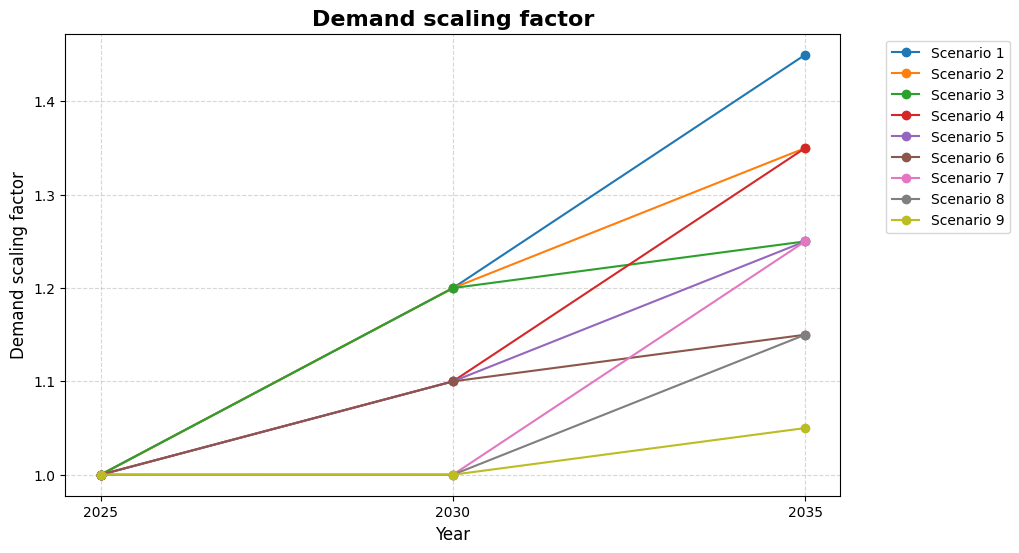

In [43]:
years = [2025, 2030, 2035]
scenarios = ['Scenario 1', 'Scenario 2', 'Scenario 3', 'Scenario 4',
             'Scenario 5', 'Scenario 6', 'Scenario 7', 'Scenario 8', 'Scenario 9']

node_data = demand_scaling_factor['value'].tolist()
node_data = [-x for x in node_data]

data = {
    'Scenario 1': [node_data[0], node_data[1], node_data[4]],
    'Scenario 2': [node_data[0], node_data[1], node_data[5]],
    'Scenario 3': [node_data[0], node_data[1], node_data[6]],
    'Scenario 4': [node_data[0], node_data[2], node_data[7]],
    'Scenario 5': [node_data[0], node_data[2], node_data[8]],
    'Scenario 6': [node_data[0], node_data[2], node_data[9]],
    'Scenario 7': [node_data[0], node_data[3], node_data[10]],
    'Scenario 8': [node_data[0], node_data[3], node_data[11]],
    'Scenario 9': [node_data[0], node_data[3], node_data[12]]
}

df = pd.DataFrame(data, index=years)

plt.figure(figsize=(10,6))

for scenario in scenarios:
    plt.plot(df.index, df[scenario], label=scenario, marker='o')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Demand scaling factor', fontsize=12)
plt.title('Demand scaling factor', fontsize=16, fontweight='bold')
plt.xticks([2025,2030,2035])
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

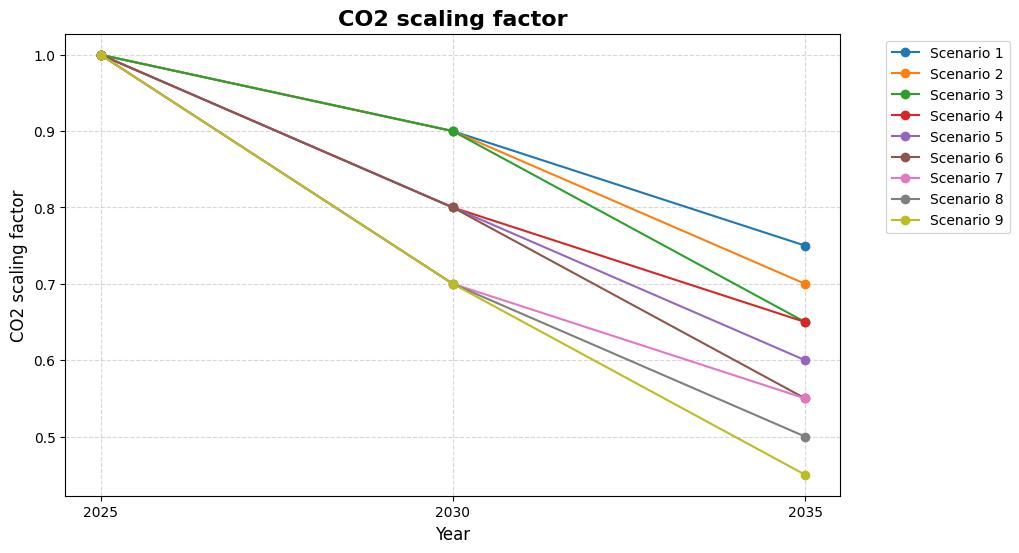

In [46]:
years = [2025, 2030, 2035]
scenarios = ['Scenario 1', 'Scenario 2', 'Scenario 3', 'Scenario 4',
             'Scenario 5', 'Scenario 6', 'Scenario 7', 'Scenario 8', 'Scenario 9']

node_data = co2_budget_scaling_factor['value'].tolist()
#node_data = [-x for x in node_data]

data = {
    'Scenario 1': [node_data[0], node_data[1], node_data[4]],
    'Scenario 2': [node_data[0], node_data[1], node_data[5]],
    'Scenario 3': [node_data[0], node_data[1], node_data[6]],
    'Scenario 4': [node_data[0], node_data[2], node_data[7]],
    'Scenario 5': [node_data[0], node_data[2], node_data[8]],
    'Scenario 6': [node_data[0], node_data[2], node_data[9]],
    'Scenario 7': [node_data[0], node_data[3], node_data[10]],
    'Scenario 8': [node_data[0], node_data[3], node_data[11]],
    'Scenario 9': [node_data[0], node_data[3], node_data[12]]
}

df = pd.DataFrame(data, index=years)

plt.figure(figsize=(10,6))

for scenario in scenarios:
    plt.plot(df.index, df[scenario], label=scenario, marker='o')

plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 scaling factor', fontsize=12)
plt.title('CO2 scaling factor', fontsize=16, fontweight='bold')
plt.xticks(years)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()